## Construct test cases
Set up waveform and response modules, explore mass/SNR scaling with redshift, then generate a config file and SLURM script in one step.

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from astropy.cosmology import Planck15
import astropy.units as u
from scipy.optimize import brentq

from lisaconstants import ASTRONOMICAL_YEAR
from lisaorbits import OEMOrbits
from mojito import MojitoL1File
from ruamel.yaml import YAML
from scipy.signal.windows import tukey

from src.noise import build_inv_covariance
from src.utils import inband_freqs, inner_prod_tdi, mismatch_tdi
from src.waveform import (
    ResponseConfig,
    WaveformConfig,
    build_response,
    param_names_for,
)

/data/leuven/367/vsc36785/miniconda3/envs/emri_env_ddpc/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# File path constants
ORBIT_FILE = "/data/leuven/367/vsc36785/LISA/Mojito_analysis/esa-trailing-orbits-mojito_validation_test_2.h5"
MOJITO_L1  = (
    "/scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/"
    "mojito_light_v1_0_0/data/EMRI/L1/"
    "EMRI_731d_2.5s_L1_source0_0_20251203T225446987631Z.h5"
)
NOISE_FILE = (
    "/scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/"
    "mojito_light_v1_0_0/data/NOISE/L1/"
    "NOISE_731d_2.5s_L1_source0_0_20251206T220508924302Z.h5"
)

In [3]:
# Mojito L1 timing
with MojitoL1File(MOJITO_L1) as l1:
    ts           = l1.tdis.time_sampling
    t0_l1        = float(ts.t0)
    mojito_dt    = float(ts.dt)
    central_freq = float(l1.laser_frequency)

print(f"Mojito L1:  t0={t0_l1:.3f} s   dt={mojito_dt:.3f} s   f_laser={central_freq:.6e} Hz")

# Keep pristine copies for YAML serialisation — WaveformConfig mutates the
# dicts it receives in-place (injects class references), so we pass copies.
INJ_INSPIRAL_KWARGS  = {"DENSE_STEPPING": 0, "max_init_len": 1000}
INJ_SUMMATION_KWARGS = {"pad_output": True}
INJ_AMPLITUDE_KWARGS = {}

inj_wcfg = WaveformConfig(
    model="1PAT1R",
    dt=5.0,
    T=2.0,
    evolve_chi1=True,
    include_1PA_amps=True,
    inspiral_kwargs=dict(INJ_INSPIRAL_KWARGS),
    summation_kwargs=dict(INJ_SUMMATION_KWARGS),
    amplitude_kwargs=dict(INJ_AMPLITUDE_KWARGS),
)
print(f"Injection : {inj_wcfg.model}  evolve_chi1={inj_wcfg.evolve_chi1}  1PA_amps={inj_wcfg.include_1PA_amps}")

Mojito L1:  t0=97729939.828 s   dt=2.500 s   f_laser=2.816000e+14 Hz
Injection : 1PAT1R  evolve_chi1=True  1PA_amps=True


In [4]:
REC_INSPIRAL_KWARGS  = {"DENSE_STEPPING": 0, "max_init_len": 1000}
REC_SUMMATION_KWARGS = {"pad_output": True}
REC_AMPLITUDE_KWARGS = {}

rec_wcfg = WaveformConfig(
    model="1PAT1R", # 1PAT1R or 0PA_Kerr
    dt=5.0,
    T=2.0,
    evolve_chi1=True,
    include_1PA_amps=True,
    lmax=5,
    inspiral_kwargs=dict(REC_INSPIRAL_KWARGS),
    summation_kwargs=dict(REC_SUMMATION_KWARGS),
    amplitude_kwargs=dict(REC_AMPLITUDE_KWARGS),
)
print(f"Recovery  : {rec_wcfg.model}  evolve_chi1={rec_wcfg.evolve_chi1}  1PA_amps={rec_wcfg.include_1PA_amps}")
if inj_wcfg.model != rec_wcfg.model:
    print(" Models differ — systematic bias is expected.")

Recovery  : 1PAT1R  evolve_chi1=True  1PA_amps=True


In [5]:
# Shared response config (same for injection and recovery)
resp_cfg = ResponseConfig(
    orbit_file=ORBIT_FILE,
    tdi_gen="2nd generation",
    tdi_chan="XYZ",
    order=40,
    offset=550.0,
    n_samples_delay=1000,
    t_buffer=10000.0,
    flip_hx=True,
    is_ecliptic_latitude=False,
)
print(f"Response  : {resp_cfg.tdi_chan}  {resp_cfg.tdi_gen}  order={resp_cfg.order}")

Response  : XYZ  2nd generation  order=40


In [6]:
# Derived timing (mirrors PE_response.py)
DT         = inj_wcfg.dt
oem_orbits = OEMOrbits.from_included("esa-trailing")
t0_orbits  = float(oem_orbits.t_start) + 10.0
T_response = (
    inj_wcfg.T
    + (2 * resp_cfg.offset + 2 * resp_cfg.n_samples_delay * DT) / ASTRONOMICAL_YEAR
)
t0_l0  = t0_l1 - resp_cfg.n_samples_delay * mojito_dt
t_init = t0_l0 - resp_cfg.offset

print(f"t_init     = {t_init:.3f} s")
print(f"T_response = {T_response:.6f} yr")

print("\nBuilding injection response ...")
inj_response = build_response(inj_wcfg, resp_cfg, t_init, t0_orbits, T_response, use_gpu=True)

print("Building recovery response ...")
rec_response = build_response(rec_wcfg, resp_cfg, t_init, t0_orbits, T_response, use_gpu=True)

print("Done.")

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


t_init     = 97726889.828 s
T_response = 2.000352 yr

Building injection response ...
Building recovery response ...
Done.


## Cosmology and mass scaling

Helper functions for computing the luminosity distance (Planck15), visualising how source-frame masses and the SNR proxy scale with redshift, and finding the redshift that yields a desired SNR for fixed detector-frame masses.

Key relations:
- $m_{\rm det} = m_{\rm src}\,(1+z)$
- $d_L = d_L(z)$ from Planck15 cosmology
- ${\rm SNR} \propto \mu_{\rm src}/d_L = \mu_{\rm det}/[(1+z)\,d_L(z)]$

In [7]:
def get_D_at_z(z):
    """Luminosity distance at redshift z under Planck15 cosmology [Gpc]."""
    return float(Planck15.luminosity_distance(z).to(u.Gpc).value)


def source_params_from_detector(d_L, M_det, mu_det):
    """
    Given a luminosity distance and detector-frame masses, return the
    redshift and source-frame masses to place in the YAML config.

    The config stores source-frame masses; PE_response.py redshifts them
    internally via  m_det = m_src * (1 + z).  The SNR scales as
        SNR ~ mu_src / d_L = mu_det / [(1+z) · d_L]
    so choosing d_L controls the SNR for fixed detector-frame masses.

    Parameters
    ----------
    d_L    : luminosity distance [Gpc]
    M_det  : detector-frame primary mass [M_sun]
    mu_det : detector-frame secondary mass [M_sun]

    Returns
    -------
    z      : redshift consistent with d_L under Planck15
    M_src  : source-frame primary mass [M_sun]   = M_det  / (1 + z)
    mu_src : source-frame secondary mass [M_sun] = mu_det / (1 + z)
    """
    z = brentq(lambda zz: get_D_at_z(zz) - d_L, 1e-4, 20.0, xtol=1e-6)
    return z, M_det / (1.0 + z), mu_det / (1.0 + z)

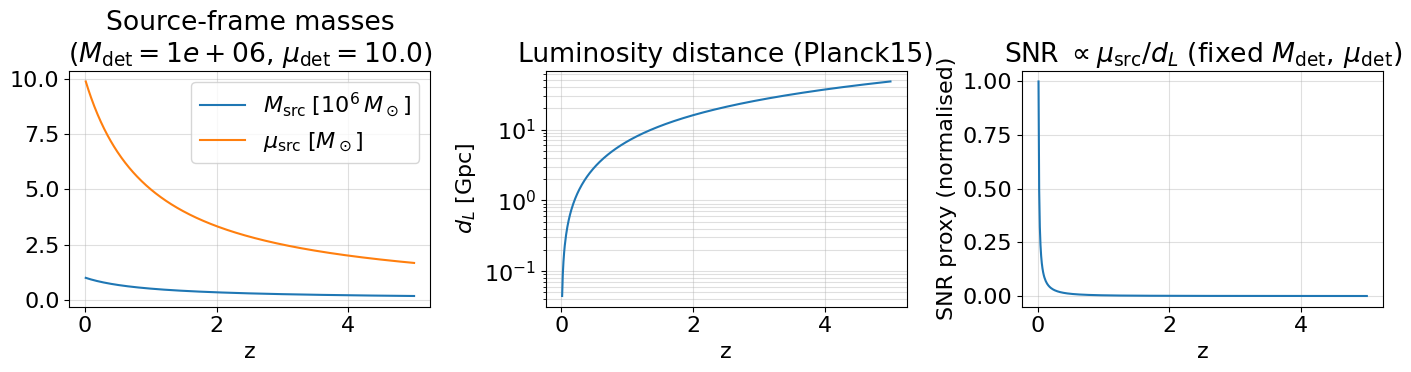

In [8]:
# Illustrate mass and distance scaling for a representative detector-frame mass pair.
# Edit M_det_ex / mu_det_ex to match your planned source.
M_det_ex  = 1e6    # primary,   detector frame [M_sun]
mu_det_ex = 10.0   # secondary, detector frame [M_sun]

z_arr       = np.linspace(0.01, 5.0, 500)
dL_arr      = np.array([get_D_at_z(z) for z in z_arr])
M_src_arr   = M_det_ex  / (1.0 + z_arr)
mu_src_arr  = mu_det_ex / (1.0 + z_arr)
snr_proxy   = 1.0 / ((1.0 + z_arr) * dL_arr)   # SNR ∝ mu_src/d_L (normalised)
snr_proxy  /= snr_proxy.max()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(z_arr, M_src_arr / 1e6, label=r"$M_{\rm src}\;[10^6\,M_\odot]$")
axes[0].plot(z_arr, mu_src_arr,       label=r"$\mu_{\rm src}\;[M_\odot]$")
axes[0].set_xlabel("z")
axes[0].set_title(
    f"Source-frame masses\n"
    rf"($M_{{\rm det}}={M_det_ex:.0e}$, $\mu_{{\rm det}}={mu_det_ex}$)"
)
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].semilogy(z_arr, dL_arr)
axes[1].set_xlabel("z"); axes[1].set_ylabel("$d_L$ [Gpc]")
axes[1].set_title("Luminosity distance (Planck15)")
axes[1].grid(alpha=0.4, which="both")

axes[2].plot(z_arr, snr_proxy)
axes[2].set_xlabel("z"); axes[2].set_ylabel("SNR proxy (normalised)")
axes[2].set_title(r"SNR $\propto \mu_{\rm src}/d_L$ (fixed $M_{\rm det},\,\mu_{\rm det}$)")
axes[2].grid(alpha=0.4)

fig.tight_layout(); plt.show()

## Mismatch and SNR utilities

Compute SNR and mismatch between injection and recovery using the noise-weighted inner product.

In [9]:
def snr_tdi(h_fft: cp.ndarray, inv_cov: cp.ndarray) -> float:
    return float(cp.sqrt(inner_prod_tdi(h_fft, h_fft, inv_cov)))


def _to_vector(params: dict, model: str) -> list:
    """Convert a params dict to the ordered vector expected by the waveform model."""
    z   = float(params.get("z", 0.0))
    vec = []
    for n in param_names_for(model):
        val = float(params[n])
        if n in ("M", "mu"):
            val *= (1.0 + z)
        vec.append(val)
    return vec

In [10]:
# Nominal grid for inverse covariance (rebuilt automatically if N_t differs).
N_t_nominal = int(round(T_response * ASTRONOMICAL_YEAR / DT))
freqs_inband_nom, mask_nom = inband_freqs(N_t_nominal, DT, filter_freq=True)

print(f"N_t_nominal = {N_t_nominal}   n_inband = {int(mask_nom.sum())}")
print("Building inverse covariance ...")

inv_cov, psd_diag = build_inv_covariance(
    NOISE_FILE, central_freq,
    cp.asnumpy(freqs_inband_nom), DT, N_t_nominal,
    channels=resp_cfg.tdi_chan,
)
print(f"inv_cov shape: {inv_cov.shape}")

N_t_nominal = 12625480   n_inband = 6312109
Building inverse covariance ...
inv_cov shape: (6312109, 3, 3)


### Mojito Heavy sources

In [ ]:
import os
os.listdir('../../../MojitoHeavy')

In [58]:
# load quasi-circular catalog and assign parameters to variables
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
import pandas as pd
import seaborn as sns
from astropy.coordinates import CartesianRepresentation, ICRS
import astropy.units as u
import os

base_cat = pd.read_csv("../../../MojitoHeavy/wavelet_SNR_cat.csv")
base_cat = base_cat.drop(columns=["Unnamed: 0"], errors="ignore")
base_cat = base_cat.rename(columns={"source_index": "cat_ID"})
base_cat = base_cat.reset_index(drop=True)

cat_quasi_circ = pd.read_csv("../../../MojitoHeavy/wavelet_SNR_quasicircular_cat.csv")
cat_quasi_circ = cat_quasi_circ.drop(columns=["Unnamed: 0"], errors="ignore")
cat_quasi_circ = cat_quasi_circ.rename(columns={"source_index": "cat_ID"})
cat_quasi_circ = cat_quasi_circ.reset_index(drop=True)

# rename for readability

Good_sources = [
    351, 421, 699, 15833, 12642,
    13749, 10483, 9005, 1999, 4847,
    11869, 12806, 15078, 6237, 7187,
]

base_cat["selected_circular"] = base_cat["cat_ID"].isin(Good_sources).astype(int)
np.random.seed(42)
# randomly sample secondary spin for circular sources
chi2_vals = np.random.uniform(-0.999, 0.999, size=len(Good_sources))

good_cat = (
    cat_quasi_circ[cat_quasi_circ["cat_ID"].isin(Good_sources)]
    .copy()
    .reset_index(drop=True)
    .rename(columns={
        "M_results": "M",
        "e0_results": "e0",
        "p0_results": "p0",
        "a_results": "a",
        "z_results": "z",
        "Tgw_results": "Tgw",
    })
)
good_cat["chi2"] = chi2_vals

In [59]:
good_cat

,cat_ID,snr_catalog,snr_MojitoL,snr_wavelet,M,e0,p0,a,z,Tgw,...,p4,phiK,phiS,qK,qS,t_back,x_f,z_det,SNR_MojitoL,chi2
0,351,27.292762,23.278914,29.886948,125314.117494,0.0,26.388158,-0.000617,1.3537,1.478666,...,5.298220,3.652192,2.930067,2.185336,1.903380,1.675241,0.052336,1.3537,23.278914,-0.250669
1,421,40.094446,34.657857,47.642405,287342.588667,0.0,17.585849,0.000056,0.5960,1.820011,...,1.797849,5.031627,0.383603,0.639737,2.258354,0.509135,0.992010,0.5960,34.657857,0.900527
2,699,33.226379,26.033266,85.059218,438328.793419,0.0,12.263378,0.000022,0.2198,1.327745,...,7.329899,4.039823,4.707806,0.724733,1.070639,1.810535,-0.483110,0.2198,26.033266,0.463524
3,1999,46.351615,45.221238,41.596753,91012.281203,0.0,35.377821,0.000076,1.5214,1.334567,...,9.011847,2.680195,2.810142,1.160156,1.272172,0.163998,-0.949990,1.5214,45.221238,0.197120
4,4847,29.054365,35.534750,32.743049,177092.431135,0.0,23.675041,0.000137,0.9151,1.816208,...,8.769658,3.885775,2.700914,1.364222,1.221054,1.006574,-0.884865,0.9151,35.534750,-0.687275
5,6237,34.166182,16.522018,21.424062,81545.500006,0.0,32.153208,-0.000787,2.3878,1.794201,...,7.799978,4.871287,5.120061,0.505489,0.518127,1.155795,-0.615172,2.3878,16.522018,-0.687323
6,7187,28.691606,34.285892,24.350218,259537.430099,0.0,16.293371,-0.000056,1.6443,1.300837,...,8.870903,2.216480,5.394369,1.505212,1.619181,0.235693,-0.875710,1.6443,34.285892,-0.882949
7,9005,33.255679,32.590800,28.014520,251304.346436,0.0,14.651305,-0.000143,0.7972,1.639571,...,8.683132,3.563167,0.061741,1.522281,1.513864,0.486749,-0.857301,0.7972,32.590800,0.731620
8,10483,65.223007,59.188937,66.587404,166724.721255,0.0,19.194243,0.000219,0.1721,1.406549,...,2.059870,5.964083,0.417314,2.455819,0.594629,1.800260,0.879208,0.1721,59.188937,0.202028
9,11869,18.052866,15.837825,17.000865,132770.013679,0.0,19.371674,0.000056,1.4305,1.910320,...,4.505566,1.361182,0.844310,1.550588,1.478689,0.969138,0.258236,1.4305,15.837825,0.415729


In [60]:
good_cat.keys()

Index(['cat_ID', 'snr_catalog', 'snr_MojitoL', 'snr_wavelet', 'M', 'e0', 'p0',
       'a', 'z', 'Tgw', 'M_det', 'Phi_phi0', 'Phi_r0', 'Phi_theta0', 'R_LSO',
       'SNR', 'Tgw_det', 'Y0', 'Y4', 'Y_f', 'a_det', 'dist', 'e0_det', 'e4',
       'e_f', 'error', 'inc_f', 'max_f', 'min_f', 'mu', 'n_bin', 'p0_det',
       'p4', 'phiK', 'phiS', 'qK', 'qS', 't_back', 'x_f', 'z_det',
       'SNR_MojitoL', 'chi2'],
      dtype='str')

In [61]:
# narrow down source index
src_index = 9

In [ ]:
# catalog has source frame masses
M = good_cat.M[src_index]
mu = good_cat.mu[src_index]
a = good_cat.a[src_index]
p0 = good_cat.p0[src_index]
e0 = 0.0
chi2 = good_cat.chi2[src_index]
d_L= good_cat.dist[src_index]
z= good_cat.z[src_index]

theta_S = good_cat.qS[src_index]
phi_S = good_cat.phiS[src_index] 
theta_K = good_cat.qK[src_index] 
phi_K =good_cat.phiK[src_index]  
Phi_phi0  =good_cat.Phi_phi0[src_index]
Phi_theta0 = good_cat.Phi_theta0[src_index]
Phi_r0 =good_cat.Phi_r0[src_index]

### Random parameters

In [17]:
M_det  = 5e6    # detector-frame primary mass [M_sun]
mu_det = 500.0  # detector-frame secondary mass [M_sun]
# d_L    = 1.0    # luminosity distance [Gpc]
z =0.001
# compute distance from z
dist = get_D_at_z(z)
z, M, mu = source_params_from_detector(dist, M_det, mu_det)
print(f"d_L = {dist} Gpc  to  z = {z:.4f}")
print(f"M_src  = {M:.4e} M_sun   (M_det  = {M_det:.4e})")
print(f"mu_src = {mu:.4e} M_sun   (mu_det = {mu_det:.4e})")


a    = 0.02   # primary spin [+/- 23*epsilon ]
p0   = 29.988286969253295  # initial semi-latus rectum [M]
e0   = 0.0      # initial eccentricity
chi2 = 15      # secondary spin (1PAT1R only)

# Extrinsic / angular parameters (fix seed for reproducibility)
rng = np.random.default_rng(seed=42)
theta_S    = rng.uniform(0.0, np.pi)
phi_S      = rng.uniform(0.0, 2 * np.pi)
theta_K    = rng.uniform(0.0, np.pi)
phi_K      = rng.uniform(0.0, 2 * np.pi)
Phi_phi0   = rng.uniform(0.0, 2 * np.pi)
Phi_theta0 = rng.uniform(0.0, 2 * np.pi)
Phi_r0     = rng.uniform(0.0, 2 * np.pi)

d_L = 0.004429032864588028 Gpc  to  z = 0.0010
M_src  = 4.9950e+06 M_sun   (M_det  = 5.0000e+06)
mu_src = 4.9950e+02 M_sun   (mu_det = 5.0000e+02)


In [18]:
inj_params = dict(
    M=M, mu=mu, a=a, p0=p0, e0=e0, chi2=chi2, x_I0=1.0, d_L=dist,
    theta_S=theta_S, phi_S=phi_S,
    theta_K=theta_K, phi_K=phi_K,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
    z=z,
)

print("\nInjection params (source frame):")
for k, v in inj_params.items():
    print(f"  {k:12s} = {v:.6g}")


Injection params (source frame):
  M            = 4.99501e+06
  mu           = 499.501
  a            = 0.02
  p0           = 29.9883
  e0           = 0
  chi2         = 15
  x_I0         = 1
  d_L          = 0.00442903
  theta_S      = 2.43145
  phi_S        = 2.75755
  theta_K      = 2.69736
  phi_K        = 4.38169
  Phi_phi0     = 0.591734
  Phi_theta0   = 6.13002
  Phi_r0       = 4.78238
  z            = 0.000999877


In [19]:
# Recovery params: same physical source in the recovery model's parameter space.
# Edit here to probe systematics (e.g. different evolve_chi1 / include_1PA_amps).
rec_params = dict(inj_params)

In [20]:
windowing = True

inj_vec = _to_vector(inj_params, inj_wcfg.model)
rec_vec = _to_vector(rec_params, rec_wcfg.model)

# Generate injection TDI
print("Generating injection TDI ...")
xyz_inj = inj_response(*inj_vec)
N_t     = xyz_inj.shape[1]
window  = cp.asarray(tukey(N_t, alpha=0.01)) if windowing else cp.ones(N_t)
freqs_inband, mask = inband_freqs(N_t, DT, filter_freq=True)
xyz_inj_fft = cp.fft.rfft(xyz_inj * window, axis=1)[:, mask]
print(f"  N_t = {N_t}   n_inband = {int(mask.sum())}")

# Rebuild inv_cov on the exact grid if N_t differed from the nominal estimate
if N_t != N_t_nominal:
    print(f"  N_t differs from nominal ({N_t_nominal}) — rebuilding inv_cov ...")
    inv_cov, psd_diag = build_inv_covariance(
        NOISE_FILE, central_freq,
        cp.asnumpy(freqs_inband), DT, N_t,
        channels=resp_cfg.tdi_chan,
    )

Generating injection TDI ...
  N_t = 12625479   n_inband = 6312108
  N_t differs from nominal (12625480) — rebuilding inv_cov ...


In [21]:
# Generate recovery TDI at injection params and compute diagnostics
print("Generating recovery TDI at injection params ...")
xyz_rec     = rec_response(*rec_vec)
xyz_rec_fft = cp.fft.rfft(xyz_rec * window, axis=1)[:, mask]

snr_inj = snr_tdi(xyz_inj_fft, inv_cov)
mm      = mismatch_tdi(xyz_inj_fft, xyz_rec_fft, inv_cov)
snr_res = snr_tdi(xyz_inj_fft - xyz_rec_fft, inv_cov)

print(f"\nInjection SNR           : {snr_inj:.2f}")
print(f"Mismatch (inj vs rec)   : {mm:.3e}")
print(f"SNR of residual         : {snr_res:.2f}")

if snr_inj < 20:
    print("WARNING: SNR below 20 — source may not be recoverable.")

Generating recovery TDI at injection params ...

Injection SNR           : 73.19
Mismatch (inj vs rec)   : 0.000e+00
SNR of residual         : 0.00


In [16]:
# ── Optional: adjust d_L to hit a desired SNR ────────────────────────────────
# SNR ∝ mu_det / [(1+z) · d_L].  For fixed detector-frame masses the ratio
# (1+z)·d_L is a monotone function of d_L (via Planck15), so:
#
#   d_L_new ≈ d_L_ref * snr_inj / target_snr   (exact only at low z,
#                                                 use as a starting guess)
#
# Then call source_params_from_detector with the new d_L to get the exact
# z and source-frame masses.  Uncomment and adapt:

# target_snr = 50.0
# d_L_new    = d_L * snr_inj / target_snr          # approximate starting guess
# z_new, M_new, mu_new = source_params_from_detector(d_L_new, M_det, mu_det)
# print(f"target SNR ≈ {target_snr}")
# print(f"  d_L_new = {d_L_new:.3f} Gpc   z_new = {z_new:.4f}")
# print(f"  M_src   = {M_new:.4e} M_sun   mu_src = {mu_new:.4e} M_sun")
# # Update d_L, M_det, mu_det in the inj_params cell above and rerun.

## Generate config and SLURM script

Set `RUN_NAME` and `RUNTIME` in the cell below. The name is propagated automatically to:
- `Sampler/name` inside the YAML config
- `--job-name` and the filename of the SLURM script

Injection parameters are taken from `inj_params` defined above.

In [22]:
src_index = 3

In [23]:
# ─── Specify these before generating ─────────────────────────────────────────
RUN_NAME  = f"Review_test_{src_index}_inj_1PA_rec_1PA"   # → config/{RUN_NAME}.yaml  and  scripts/submit_{RUN_NAME}.sh
RUNTIME   = "20:00:00"      # SLURM wall-time  (hh:mm:ss)

# Sampler / fixed-parameter settings
FIXED_PARAMS = ["x_I0", "e0", "Phi_theta0", "Phi_r0"]
N_TEMPS      = 2
N_WALKERS    = 40
NUM_SAMPLES  = 10000
D_SCALE      = 5    # prior half-width scale (see PE_response.py)

In [24]:
def _wf_block(wcfg, inspiral_kwargs, summation_kwargs, amplitude_kwargs):
    """Build a YAML-serializable waveform block from a WaveformConfig.

    The raw *_kwargs dicts are passed explicitly because WaveformConfig may
    inject non-serializable class references into the stored copies.
    """
    block = {
        "model":                    wcfg.model,
        "evolve_chi1":              wcfg.evolve_chi1,
        "include_1PA_amps":         wcfg.include_1PA_amps,
        "dt":                       wcfg.dt,
        "T":                        wcfg.T,
        "mode_selection_threshold": wcfg.mode_selection_threshold,
        "inspiral_kwargs":          dict(inspiral_kwargs),
        "summation_kwargs":         dict(summation_kwargs),
        "amplitude_kwargs":         dict(amplitude_kwargs),
    }
    if wcfg.lmax is not None:
        block["lmax"] = wcfg.lmax
    return block


cfg_out = {
    "Data": {
        "orbit_file":     ORBIT_FILE,
        "mojito_l1_file": MOJITO_L1,
        "noise_file":     NOISE_FILE,
    },
    "Injection": {
        "EMRI":     {k: float(v) for k, v in inj_params.items()},
        "Waveform": _wf_block(inj_wcfg, INJ_INSPIRAL_KWARGS, INJ_SUMMATION_KWARGS, INJ_AMPLITUDE_KWARGS),
    },
    "Response": {
        "tdi_gen":              resp_cfg.tdi_gen,
        "tdi_chan":             resp_cfg.tdi_chan,
        "order":                resp_cfg.order,
        "offset":               resp_cfg.offset,
        "n_samples_delay":      resp_cfg.n_samples_delay,
        "t_buffer":             resp_cfg.t_buffer,
        "flip_hx":              resp_cfg.flip_hx,
        "is_ecliptic_latitude": resp_cfg.is_ecliptic_latitude,
    },
    "Recovery": {
        "Waveform": _wf_block(rec_wcfg, REC_INSPIRAL_KWARGS, REC_SUMMATION_KWARGS, REC_AMPLITUDE_KWARGS),
    },
    "Sampler": {
        "name":               RUN_NAME,
        "windowing":          True,
        "filter_freq":        True,
        "num_samples":        NUM_SAMPLES,
        "burn_in":            0,
        "use_gpu":            True,
        "n_temps":            N_TEMPS,
        "n_walkers":          N_WALKERS,
        "d":                  D_SCALE,
        "continue_run":       False,
        "sampling_data_path": "./sampling_data",
        "plots_path":         "./Plots",
        "fixed_params":       FIXED_PARAMS,
    },
}

In [25]:
import os

CONFIG_DIR = "config/review"
SCRIPT_DIR = "scripts/review"
os.makedirs(CONFIG_DIR, exist_ok=True)
os.makedirs(SCRIPT_DIR, exist_ok=True)

# ── Write YAML config ─────────────────────────────────────────────────────────
config_fname = f"{RUN_NAME}.yaml"
config_path  = os.path.join(CONFIG_DIR, config_fname)

yaml_obj = YAML()
yaml_obj.default_flow_style = False
yaml_obj.indent(mapping=2, sequence=4, offset=2)
with open(config_path, "w") as fh:
    yaml_obj.dump(cfg_out, fh)

# ── Write SLURM script ────────────────────────────────────────────────────────
slurm_fname = f"submit_{RUN_NAME}.sh"
slurm_path  = os.path.join(SCRIPT_DIR, slurm_fname)
HOME_VSC    = "/data/leuven/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs"

slurm_lines = [
    "#!/bin/bash -l",
    f"#SBATCH -t {RUNTIME}",
    "#SBATCH --cluster=wice",
    "#SBATCH --nodes=1",
    "#SBATCH --ntasks=18",
    "#SBATCH --partition=gpu_a100",
    "#SBATCH --gpus-per-node=1",
    "#SBATCH --output=./out/%x_%j_%a.out",
    "#SBATCH --mail-type=FAIL,BEGIN,END",
    "#SBATCH --mail-user=bert.depoorter@student.kuleuven.be",
    "#SBATCH -A lp_lisagw",
    f"#SBATCH --job-name={RUN_NAME}",
    "",
    "module load GCC/11.3.0 GSL CUDA/12 FFTW/3.3.10-GCC-11.3.0",
    "conda activate emri_env_ddpc",
    "nvidia-smi",
    "",
    f"HOME_FOLDER={HOME_VSC}",
    "SAMPLE_SCRIPTS=$HOME_FOLDER/PE_response.py",
    f"INFERENCE_PARAMS=$HOME_FOLDER/config/review/{config_fname}",
    "",
    "python $SAMPLE_SCRIPTS --config=$INFERENCE_PARAMS",
]
with open(slurm_path, "w") as fh:
    fh.write("\n".join(slurm_lines) + "\n")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Config  → {config_path}")
print(f"SLURM   → {slurm_path}")
print(f"  name       : {RUN_NAME}")
print(f"  runtime    : {RUNTIME}")
print(f"  SNR (inj)  : {snr_inj:.2f}")
print(f"  mismatch   : {mm:.3e}")
print(f"  fixed      : {FIXED_PARAMS}")

Config  → config/review/Review_test_3_inj_1PA_rec_1PA.yaml
SLURM   → scripts/review/submit_Review_test_3_inj_1PA_rec_1PA.sh
  name       : Review_test_3_inj_1PA_rec_1PA
  runtime    : 20:00:00
  SNR (inj)  : 73.19
  mismatch   : 0.000e+00
  fixed      : ['x_I0', 'e0', 'Phi_theta0', 'Phi_r0']
